# Imports & loading

In [1]:
import pandas as pd
import numpy as np
import sys
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

sys.path.append(str(Path("..").resolve()))
from src.utils import DATA_PROC, REPORTS, get_logger
from src.explain import (
    load_artifacts, compute_shap_values,
    plot_summary, plot_dependence,
    explain_single_borrower, plot_borrower_explanation
)

logger = get_logger("explainability_notebook")

train    = pd.read_parquet(DATA_PROC / "train_features.parquet")
y        = train["TARGET"].copy()
X        = train.drop(columns=["TARGET", "SK_ID_CURR"], errors="ignore")

model, feature_names = load_artifacts()
X.columns = feature_names   # ensure alignment
logger.info(f"Loaded model and {len(feature_names)} features")

2026-05-06 13:32:04 | INFO | explainability_notebook | Loaded model and 149 features


# Compute SHAP values

In [2]:
shap_values, X_sample, explainer = compute_shap_values(model, X, sample_size=2000)
print(f"SHAP values shape : {shap_values.shape}")
print(f"Mean |SHAP| (top 5):")
mean_abs = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X_sample.columns
).sort_values(ascending=False)
print(mean_abs.head(5).round(4).to_string())

2026-05-06 13:32:42 | INFO | explain | SHAP values computed — shape: (2000, 149)


SHAP values shape : (2000, 149)
Mean |SHAP| (top 5):
EXT_SOURCE_MEAN        0.5263
CREDIT_TERM            0.1688
CODE_GENDER            0.1367
NAME_EDUCATION_TYPE    0.1132
EXT_SOURCE_3           0.1075


# Global summary plot

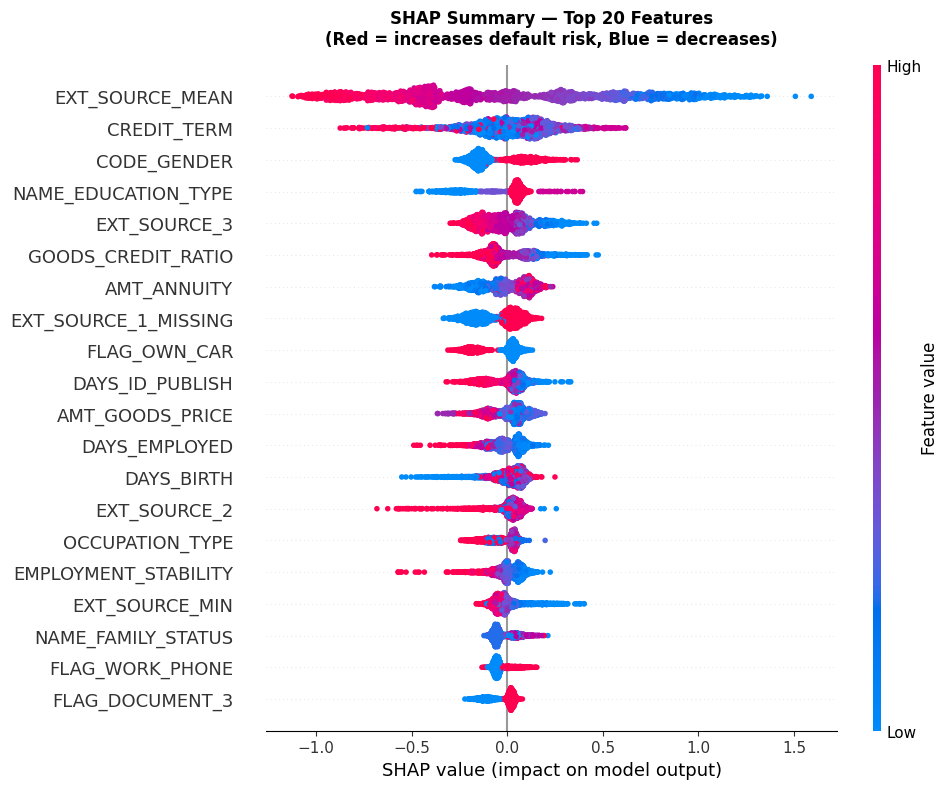

2026-05-06 13:33:18 | INFO | explain | Saved: 09_shap_summary.png


In [3]:
plot_summary(shap_values, X_sample, top_n=20)

# Dependence plots for top 3 features

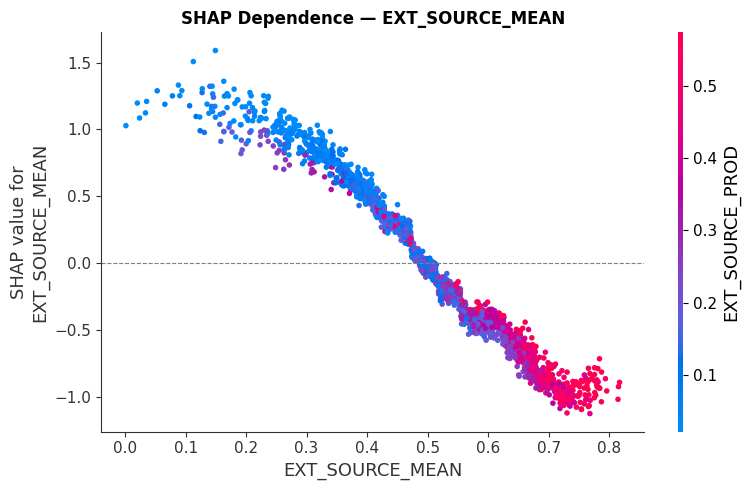

2026-05-06 13:34:03 | INFO | explain | Saved: 10_shap_dependence_ext_source_mean.png


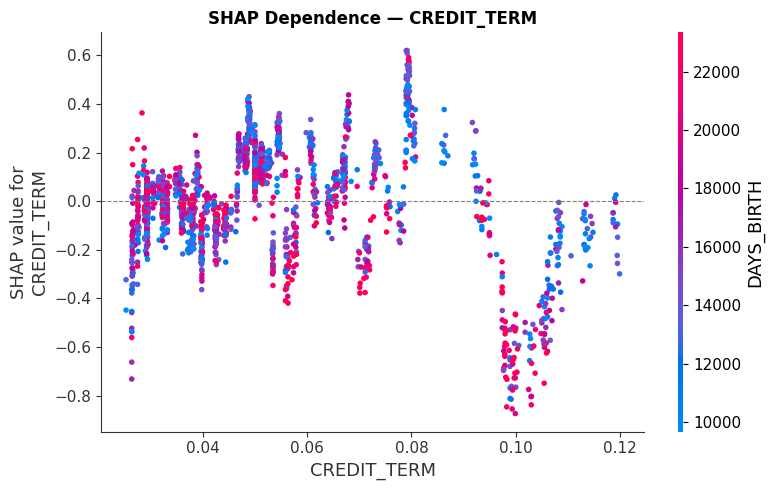

2026-05-06 13:34:03 | INFO | explain | Saved: 10_shap_dependence_credit_term.png


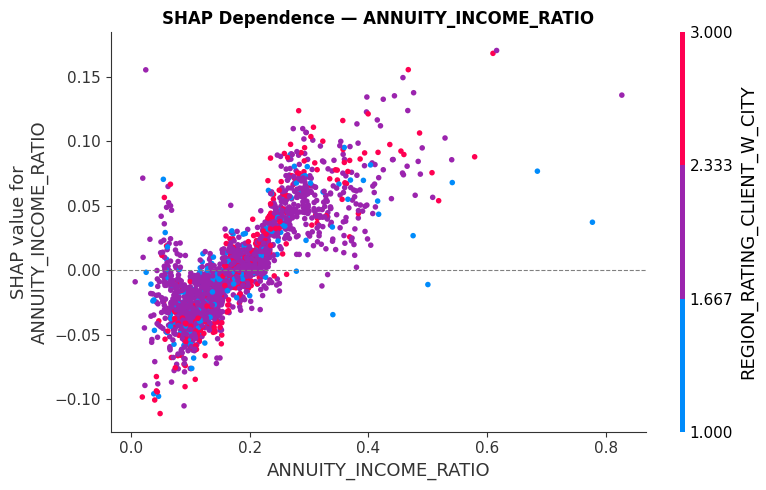

2026-05-06 13:34:04 | INFO | explain | Saved: 10_shap_dependence_annuity_income_ratio.png


In [4]:
for feature in ["EXT_SOURCE_MEAN", "CREDIT_TERM", "ANNUITY_INCOME_RATIO"]:
    plot_dependence(shap_values, X_sample, feature)

# Explain three individual borrowers


  High risk borrower (idx=698)


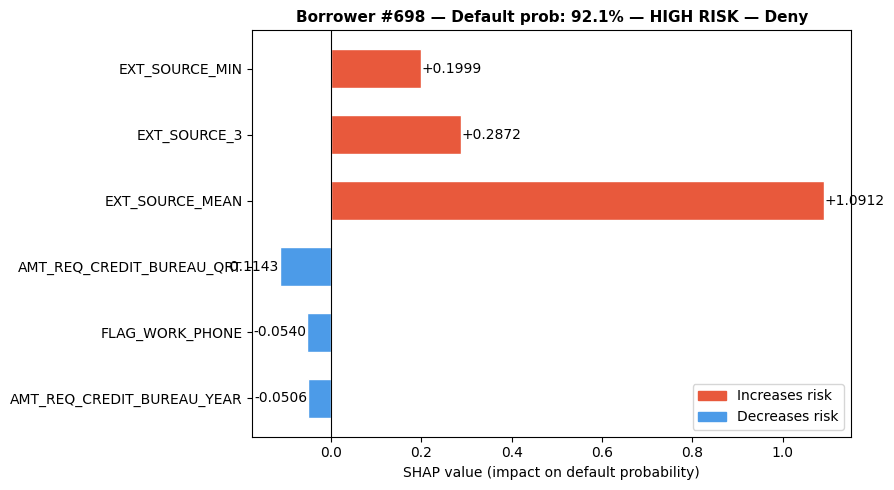

2026-05-06 13:35:02 | INFO | explain | Saved: 11_borrower_698_explanation.png


  Default probability : 92.1%
  Decision            : HIGH RISK — Deny

  Top risk drivers:
    EXT_SOURCE_MEAN                     val=0.149  shap=+1.0912
    EXT_SOURCE_3                        val=0.062  shap=+0.2872
    EXT_SOURCE_MIN                      val=0.062  shap=+0.1999

  Protective factors:
    AMT_REQ_CREDIT_BUREAU_QRT           val=1.000  shap=-0.1143
    FLAG_WORK_PHONE                     val=0.000  shap=-0.0540
    AMT_REQ_CREDIT_BUREAU_YEAR          val=0.000  shap=-0.0506

  Medium risk borrower (idx=1699)


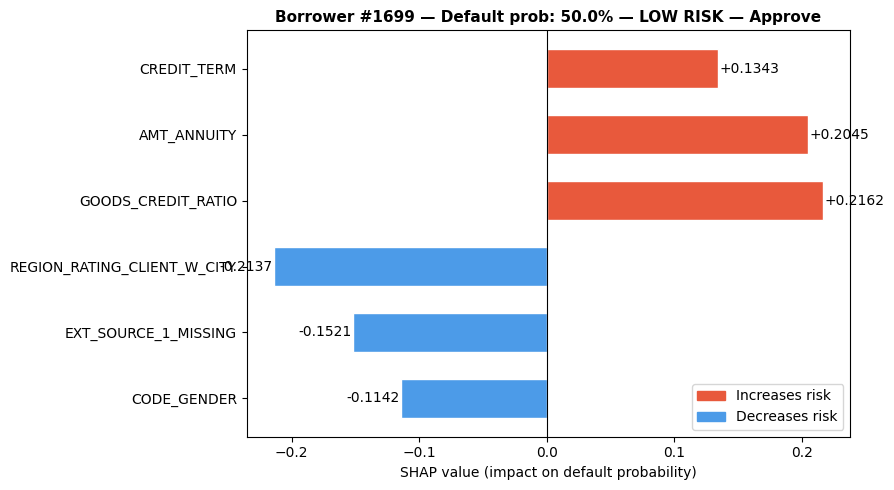

2026-05-06 13:35:02 | INFO | explain | Saved: 11_borrower_1699_explanation.png


  Default probability : 50.0%
  Decision            : LOW RISK — Approve

  Top risk drivers:
    GOODS_CREDIT_RATIO                  val=0.716  shap=+0.2162
    AMT_ANNUITY                         val=35181.000  shap=+0.2045
    CREDIT_TERM                         val=0.039  shap=+0.1343

  Protective factors:
    REGION_RATING_CLIENT_W_CITY         val=1.000  shap=-0.2137
    EXT_SOURCE_1_MISSING                val=0.000  shap=-0.1521
    CODE_GENDER                         val=0.000  shap=-0.1142

  Low risk borrower (idx=983)


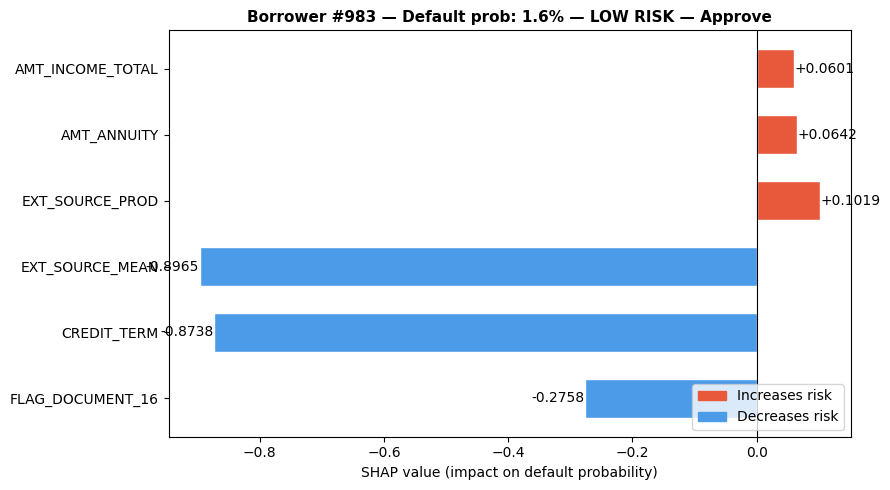

2026-05-06 13:35:02 | INFO | explain | Saved: 11_borrower_983_explanation.png


  Default probability : 1.6%
  Decision            : LOW RISK — Approve

  Top risk drivers:
    EXT_SOURCE_PROD                     val=0.477  shap=+0.1019
    AMT_ANNUITY                         val=230161.500  shap=+0.0642
    AMT_INCOME_TOTAL                    val=1575000.000  shap=+0.0601

  Protective factors:
    EXT_SOURCE_MEAN                     val=0.693  shap=-0.8965
    CREDIT_TERM                         val=0.100  shap=-0.8738
    FLAG_DOCUMENT_16                    val=1.000  shap=-0.2758


In [5]:
import json

# Pick a high-risk, medium-risk, and low-risk borrower from the sample
probs = model.predict_proba(X_sample)[:, 1]
high_risk_idx = int(np.argmax(probs))
low_risk_idx  = int(np.argmin(probs))
mid_risk_idx  = int(np.argmin(np.abs(probs - 0.5)))

for label, idx in [("High risk", high_risk_idx),
                   ("Medium risk", mid_risk_idx),
                   ("Low risk", low_risk_idx)]:
    print(f"\n{'='*55}")
    print(f"  {label} borrower (idx={idx})")
    print(f"{'='*55}")
    exp = explain_single_borrower(model, explainer, X_sample, idx)
    plot_borrower_explanation(exp)

    print(f"  Default probability : {exp['default_prob']:.1%}")
    print(f"  Decision            : {exp['decision']}")
    print(f"\n  Top risk drivers:")
    for d in exp["risk_drivers"]:
        print(f"    {d['feature']:35s} val={d['value']:.3f}  shap={d['shap']:+.4f}")
    print(f"\n  Protective factors:")
    for d in exp["protectors"]:
        print(f"    {d['feature']:35s} val={d['value']:.3f}  shap={d['shap']:+.4f}")

# Save SHAP feature ranking

In [6]:
shap_importance = pd.DataFrame({
    "feature":      X_sample.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

shap_importance.to_csv(DATA_PROC / "shap_importance.csv", index=False)
print("Top 10 features by mean |SHAP|:")
print(shap_importance.head(10).round(4).to_string(index=False))
logger.info("Saved: shap_importance.csv")

2026-05-06 13:35:47 | INFO | explainability_notebook | Saved: shap_importance.csv


Top 10 features by mean |SHAP|:
             feature  mean_abs_shap
     EXT_SOURCE_MEAN         0.5263
         CREDIT_TERM         0.1688
         CODE_GENDER         0.1367
 NAME_EDUCATION_TYPE         0.1132
        EXT_SOURCE_3         0.1075
  GOODS_CREDIT_RATIO         0.1050
         AMT_ANNUITY         0.0995
EXT_SOURCE_1_MISSING         0.0976
        FLAG_OWN_CAR         0.0840
     DAYS_ID_PUBLISH         0.0768
